In [1]:
import pandas as pd

In [6]:
#data preparation
df=pd.read_csv(r"C:\Users\Admin\Downloads\q2_customers.csv")

In [7]:
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [8]:
from sklearn.preprocessing import StandardScaler

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled

array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       ...,
       [ 0.24618021,  0.1432203 ,  0.11016555, -0.78158167, -0.79489349,
        -0.68068477],
       [-0.30890482, -0.23321247,  0.11016555, -0.27997151, -0.04966825,
         0.55095233],
       [-1.41907487, -1.2411359 ,  1.23814046, -0.79962203, -0.67404615,
        -1.50177617]])

### Why Scaling is Important

K-Means clustering is based on distance (Euclidean distance).  
If features are on different scales (e.g., age vs annual spend), variables with larger values will dominate the clustering process.

StandardScaler ensures:
- All features are on the same scale
- Each feature contributes equally to distance calculations
- More meaningful and accurate clusters are formed

C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

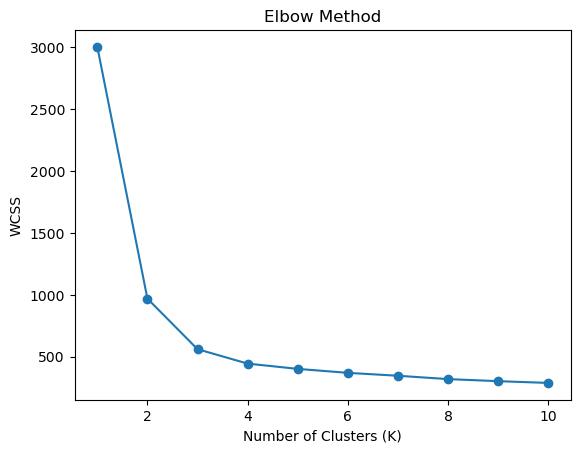

In [9]:
#Elbow Method (Choosing K)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# Elbow Method Analysis (K-Means Clustering)

## Observation
- The plot shows the relationship between:
  - **Number of Clusters (K)** on the x-axis
  - **WCSS (Within-Cluster Sum of Squares)** on the y-axis

- As the number of clusters increases, the WCSS value **decreases sharply at first** and then **starts to level off**.

## Key Insight (Elbow Point)
- The "elbow point" is where the rate of decrease in WCSS **significantly slows down**.
- From the graph, the elbow appears around:

### **K = 3**

- Up to K = 3 → Large reduction in WCSS (better clustering)
- After K = 3 → Only small improvements (diminishing returns)
- 
## Conclusion
- The optimal number of clusters for this dataset is:

### **K = 3**

- Choosing K = 3 balances:
  - Good cluster separation
  - Avoiding unnecessary complexity

## Interpretation
- Initially, adding more clusters improves grouping significantly.
- After 3 clusters, adding more clusters **does not provide much benefit**.
- Therefore, **3 clusters best represent the underlying structure of the data**.

- This result can now be used to apply **K-Means clustering with K = 3** for further analysis or segmentation.

In [10]:
#K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

df.head()

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [11]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


### Cluster Interpretation

- **Cluster 0:** Customers with moderate spending and average visit frequency  
- **Cluster 1:** High-value customers with high spending and frequent visits  
- **Cluster 2:** Low-engagement customers with low spending and fewer visits  

These segments help businesses target customers with personalized marketing strategies.

In [12]:
#Dimensionality Reduction with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [13]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

The Principal Component Analysis (PCA) reduces the dataset into two main components that capture the majority of variance.

#### Principal Component 1 (PC1)
- PC1 has strong positive loadings on:
  - `age`, `annual_spend`, `basket_size`, and `num_categories_purchased`
- It has a negative loading on `visits_per_month`

**Interpretation:**
PC1 represents **overall customer value and purchasing power**.  
Customers with high PC1 scores tend to:
- Spend more annually  
- Purchase larger baskets  
- Buy across more categories  

#### Principal Component 2 (PC2)
- PC2 is strongly influenced by:
  - `days_since_last_visit` (very high positive loading: 0.91)
- Other features have relatively smaller influence

**Interpretation:**
PC2 captures **customer recency behavior**.  
Customers with high PC2 scores:
- Have not visited recently  
- May be at risk of churn or disengagement  

### Conclusion

- **PC1** → Customer value (spending and purchasing behavior)  
- **PC2** → Customer recency (engagement level)  

Together, these components help summarize customer segments and make cluster visualization more meaningful.

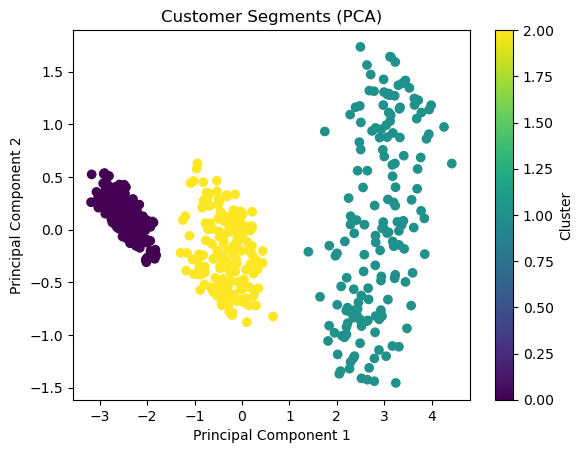

In [14]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()